In [1]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [2]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


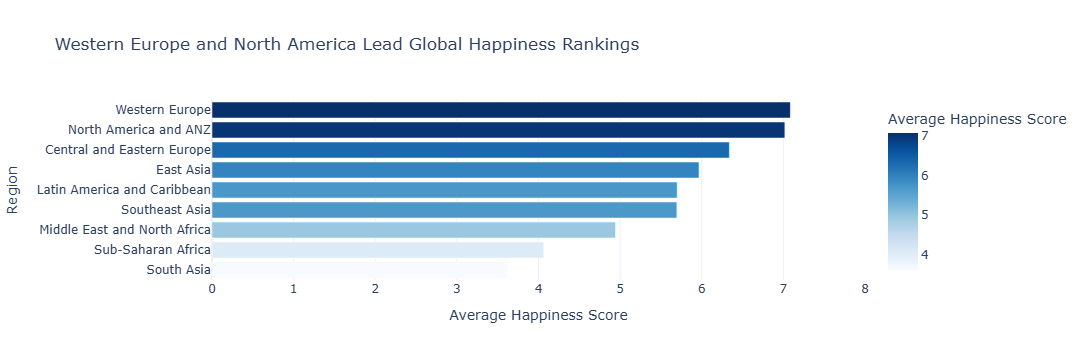

In [3]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)

# Step 2: Build your chart
# YOUR CODE HERE
fig1 = px.bar(region_avg, 
              x='Happiness_Score', 
              y='Region',
              orientation='h',
              title='Western Europe and North America Lead Global Happiness Rankings',
              labels={'Happiness_Score': 'Average Happiness Score'},
              template='plotly_white',
              color='Happiness_Score',
              color_continuous_scale='Blues')

# Rule 1: Ensure Zero Baseline
fig1.update_xaxes(range=[0, 8]) 

fig1.show()


Global average: 5.81


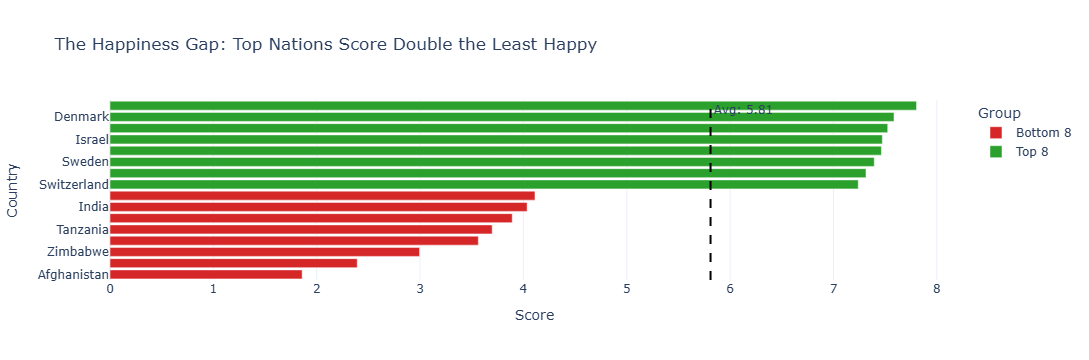

In [4]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

# Step 2: Build your chart
# YOUR CODE HERE
fig2 = px.bar(combined, 
              x='Happiness_Score', 
              y='Country',
              orientation='h',
              color='Group', 
              color_discrete_map={'Top 8': '#2ca02c', 'Bottom 8': '#d62728'},
              title='The Happiness Gap: Top Nations Score Double the Least Happy',
              labels={'Happiness_Score': 'Score'},
              template='plotly_white')

# Add the Global Average Line
fig2.add_vline(x=global_avg, line_dash="dash", line_color="black", 
               annotation_text=f"Avg: {global_avg:.2f}")

fig2.show()



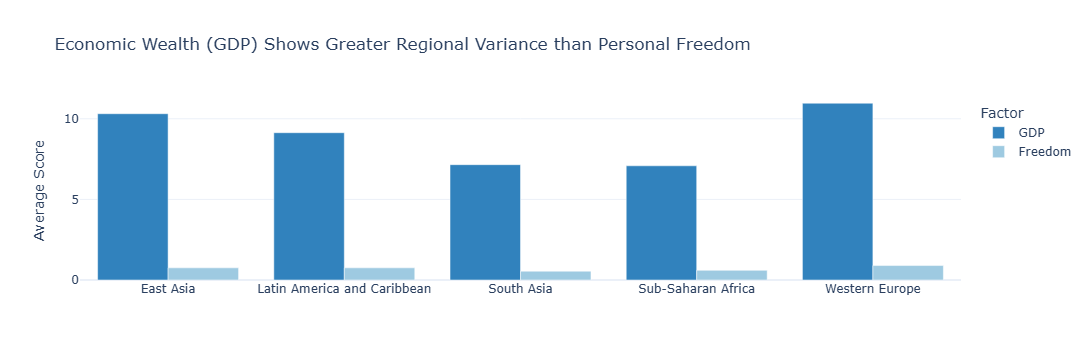

In [15]:
# Stretch goal — grouped bar chart
# YOUR CODE HERE
# 1. Prepare the data: Filter for specific regions and calculate averages
target_regions = ['Western Europe', 'Latin America and Caribbean', 'East Asia', 'Sub-Saharan Africa', 'South Asia']
df_filtered = df[df['Region'].isin(target_regions)]

# 2. Calculate mean for GDP and Freedom per region
df_grouped = df_filtered.groupby('Region')[['GDP', 'Freedom']].mean().reset_index()

# 3. Reshape the data so Plotly can group the bars
df_melted = df_grouped.melt(id_vars='Region', 
                            value_vars=['GDP', 'Freedom'], 
                            var_name='Factor', 
                            value_name='Average_Score')

# 4. Build the Grouped Bar Chart

fig3 = px.bar(df_melted, 

              x='Region', 

              y='Average_Score', 

              color='Factor', 

              barmode='group', # This creates the side-by-side "grouped" look

              title='Economic Wealth (GDP) Shows Greater Regional Variance than Personal Freedom',

              labels={'Average_Score': 'Average Score', 'Region': ''},

              template='plotly_white',

              color_discrete_map={'GDP': '#3182bd', 'Freedom': '#9ecae1'}) # Professional shades of blue



# Rule 1: Zero Baseline

fig3.update_yaxes(range=[0, df_melted['Average_Score'].max() + 0.2])



fig3.show()
